# Stock Price Prediction using Machine Learning

### Objective
The objective of this project is to predict the next day's closing stock price of Apple Inc. (AAPL) using historical stock market data.

### Dataset Source
Yahoo Finance (Retrieved using yfinance API)

### Tools and Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- yfinance
- Scikit-Learn

### Machine Learning Model
Linear Regression

# Problem Statement

Stock prices change daily based on various market factors. Predicting future stock prices can help investors and analysts make informed decisions.

The goal of this project is to use historical stock market data from Apple Inc. (AAPL) and build a machine learning model that predicts the next day's closing price using features such as Open, High, Low, and Volume.

# Import Required Libraries

In this step, all necessary libraries for data analysis, visualization, machine learning, and stock data retrieval are imported.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Load Historical Stock Data

The historical stock data of Apple Inc. (AAPL) is downloaded using the Yahoo Finance API through the yfinance library.

In [2]:
df = yf.download("AAPL",start="2020-01-01",end="2025-01-01")
df.head()

/tmp/ipykernel_7002/2770836.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL",start="2020-01-01",end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


# Explore the Dataset

Understanding the dataset structure is important before performing any analysis or modeling.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst Five Rows:")
print(df.head())

Dataset Shape:
(1258, 5)

Column Names:
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

First Five Rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333862  72.394070  71.091169  71.344039  135480400
2020-01-03  71.630646  72.389265  71.406674  71.563213  146322800
2020-01-06  72.201393  72.239927  70.503531  70.753999  118387200
2020-01-07  71.861839  72.466322  71.642681  72.211041  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200


In [4]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


#Check Missing Values

Missing values can negatively affect model performance. Therefore, they must be identified and handled.

In [5]:
print(df.isnull().sum())

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [6]:
df.dropna(inplace=True)
print("Shape After Cleaning:")
print(df.shape)

Shape After Cleaning:
(1258, 5)


# Visualize Closing Prices

This graph shows how Apple's stock closing price has changed over time.

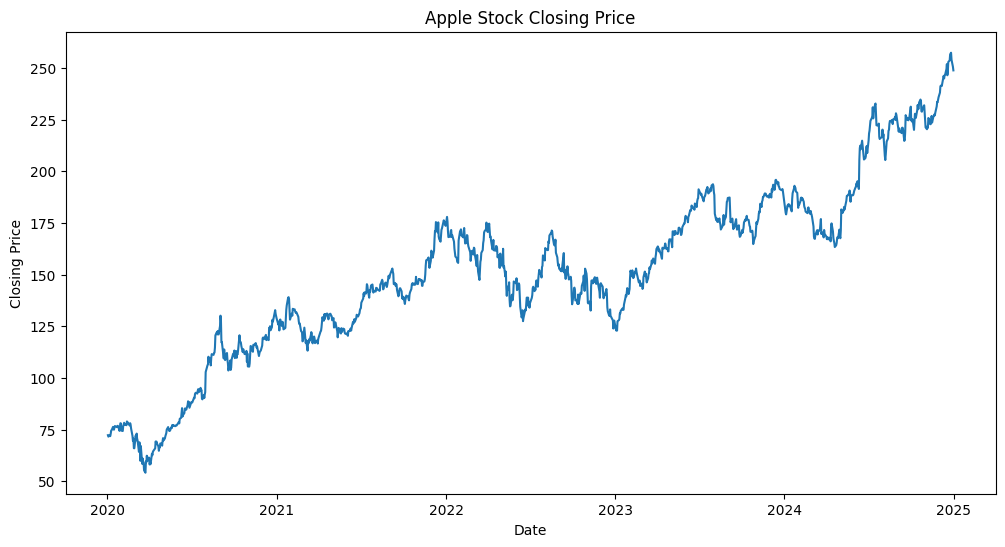

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"])
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

# Distribution of Closing Prices

The histogram shows how the stock closing prices are distributed.

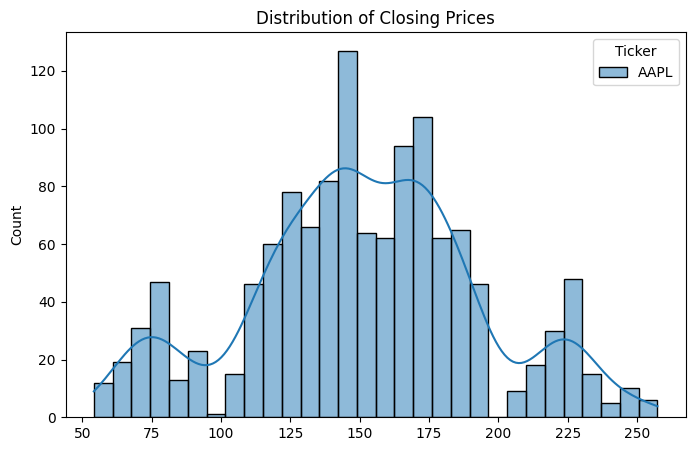

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Close"], bins=30, kde=True)
plt.title("Distribution of Closing Prices")
plt.show()

# Correlation Analysis

The heatmap helps identify relationships among stock market features.

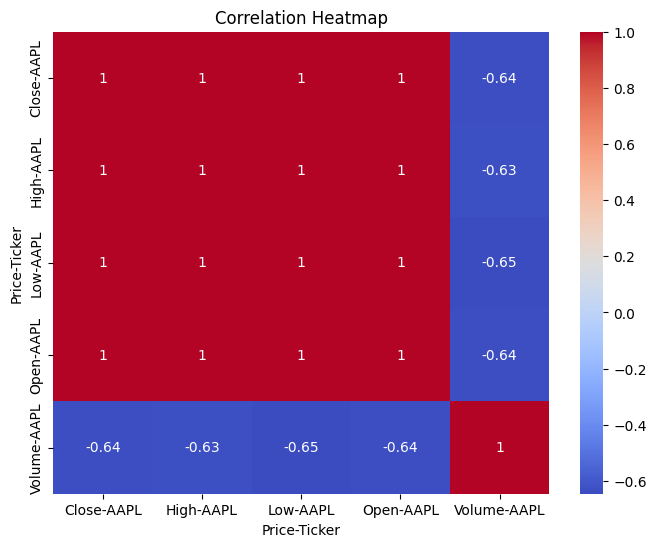

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Create Next-Day Closing Price Target

To predict the future stock price, the target variable is shifted by one day so that today's information predicts tomorrow's closing price.

In [10]:
df["Next_Close"] = df["Close"].shift(-1)
df.tail()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,257.375610
2024-12-26,257.375610,258.448771,255.994450,256.550893,27237100,253.967392
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300,250.598892
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,248.830231
2024-12-31,248.830231,251.672075,247.846510,250.837411,39480700,NaN


In [11]:
df.dropna(inplace=True)

# Select Features and Target

Input features:
- Open
- High
- Low
- Volume

Target:
- Next Day Closing Price

In [12]:
X = df[["Open", "High", "Low", "Volume"]]
y = df["Next_Close"]

# Split Dataset

The dataset is divided into training and testing sets so that model performance can be evaluated on unseen data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Train Linear Regression Model

Linear Regression is used to learn the relationship between stock market features and the next day's closing price.

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Predict Next-Day Closing Prices

The trained model predicts stock prices for the testing dataset.

In [15]:
predictions = model.predict(X_test)

# Evaluate Model Performance

The model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [16]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print("Mean Absolute Error:", round(mae,2))
print("Root Mean Squared Error:", round(rmse,2))
print("R2 Score:", round(r2,4))

Mean Absolute Error: 2.09
Root Mean Squared Error: 2.88
R2 Score: 0.9953


# Actual vs Predicted Prices

This graph compares the actual stock prices with the predicted stock prices.

In [17]:
comparison = pd.DataFrame({"Actual": y_test,"Predicted": predictions})
comparison.head()

,Actual,Predicted
Date,,
2021-09-23,143.425125,143.053737
2020-05-28,76.959595,78.223065
2020-03-17,59.547009,60.412453
2020-04-02,58.277214,58.724669
2024-04-08,167.985016,167.234907


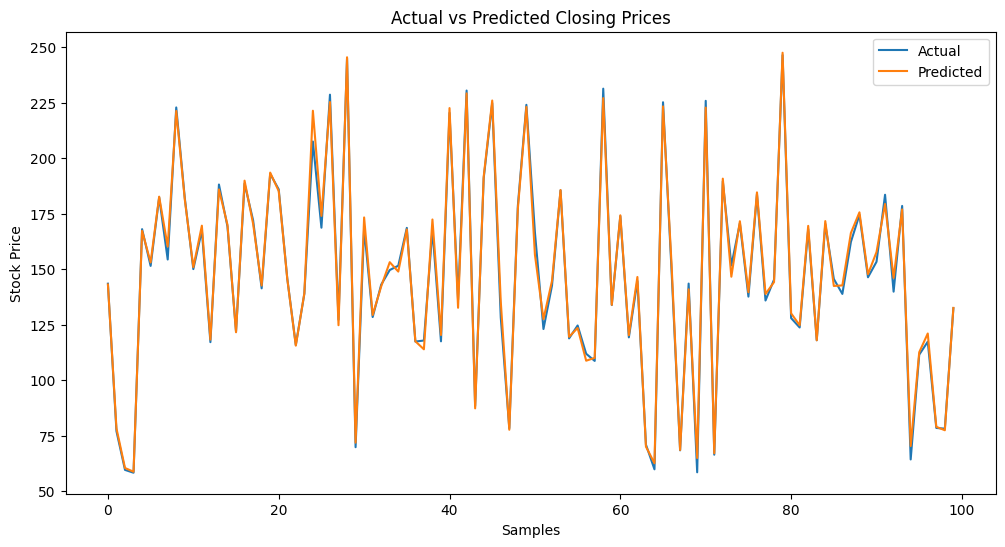

In [18]:
plt.figure(figsize=(12,6))
plt.plot(comparison["Actual"].values[:100],label="Actual")
plt.plot(comparison["Predicted"].values[:100],label="Predicted")
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Samples")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

# Prediction Error Distribution

This graph shows how prediction errors are distributed.

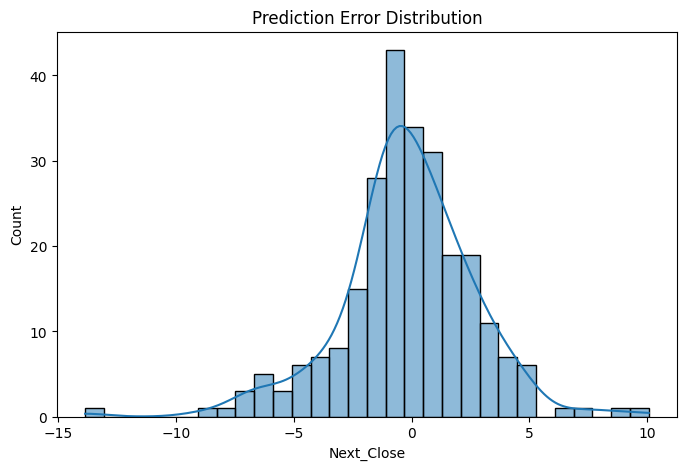

In [19]:
errors = y_test - predictions
plt.figure(figsize=(8,5))
sns.histplot(errors, bins=30, kde=True)
plt.title("Prediction Error Distribution")
plt.show()

# Results and Insights

1. Historical stock data of Apple Inc. was successfully collected using the Yahoo Finance API.

2. Open, High, Low, and Volume were used as input features.

3. Linear Regression was trained to predict the next day's closing stock price.

4. The model performance was evaluated using MAE, RMSE, and R² Score.

5. The Actual vs Predicted graph showed that the model captured the general trend of stock prices.

6. Stock market prices are influenced by many external factors, therefore predictions may not always be perfectly accurate.

# Conclusion

In this project, a machine learning model was developed to predict the next day's closing stock price of Apple Inc. using historical stock market data.

The project demonstrated data collection using APIs, data preprocessing, exploratory data analysis, regression modeling, and model evaluation. The results show that machine learning can be used to identify patterns in stock market data and generate future price estimates.